In [10]:
"""
OptiCrop - Exploratory Data Analysis (EDA)
Complete analysis with Univariate, Bivariate, and Multivariate plots
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

print("="*70)
print("📊 OPTICROP - EXPLORATORY DATA ANALYSIS")
print("="*70)
print("✅ Libraries imported successfully!")

📊 OPTICROP - EXPLORATORY DATA ANALYSIS
✅ Libraries imported successfully!


In [11]:
# ============================================
# LOAD DATASET
# ============================================

# Try multiple paths
paths = [
    '../../../Dataset/Crop_recommendation.csv',
    '../../Dataset/Crop_recommendation.csv',
    '../Dataset/Crop_recommendation.csv',
    'Dataset/Crop_recommendation.csv',
]

df = None
for path in paths:
    try:
        df = pd.read_csv(path)
        print(f"✅ Loaded from: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    print("❌ Dataset not found!")
else:
    print(f"✅ Dataset loaded successfully!")
    print(f"📏 Shape: {df.shape}")
    print(f"📋 Columns: {list(df.columns)}")

✅ Loaded from: ../../Dataset/Crop_recommendation.csv
✅ Dataset loaded successfully!
📏 Shape: (2200, 8)
📋 Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [12]:
print("\n" + "="*70)
print("📊 DATASET OVERVIEW")
print("="*70)
print(df.info())


📊 DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [13]:
print("\n" + "="*70)
print("📊 FIRST 5 ROWS")
print("="*70)
df.head()


📊 FIRST 5 ROWS


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [14]:
print("\n" + "="*70)
print("📊 LAST 5 ROWS")
print("="*70)
df.tail()


📊 LAST 5 ROWS


,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [15]:
print("\n" + "="*70)
print("📊 STATISTICAL SUMMARY")
print("="*70)
df.describe()


📊 STATISTICAL SUMMARY


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [16]:
print("\n" + "="*70)
print("🔍 NULL VALUES CHECK")
print("="*70)
print(df.isnull().sum())


🔍 NULL VALUES CHECK
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [17]:
print("\n" + "="*70)
print("🔍 DUPLICATE RECORDS")
print("="*70)
print(f"Duplicate rows: {df.duplicated().sum()}")


🔍 DUPLICATE RECORDS
Duplicate rows: 0


In [18]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
print("\n📊 FEATURE SUMMARY")
print("-"*50)
print(df[features].describe())


📊 FEATURE SUMMARY
--------------------------------------------------
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.


📈 1. UNIVARIATE ANALYSIS
✅ Saved: plots/01_univariate_histograms.png


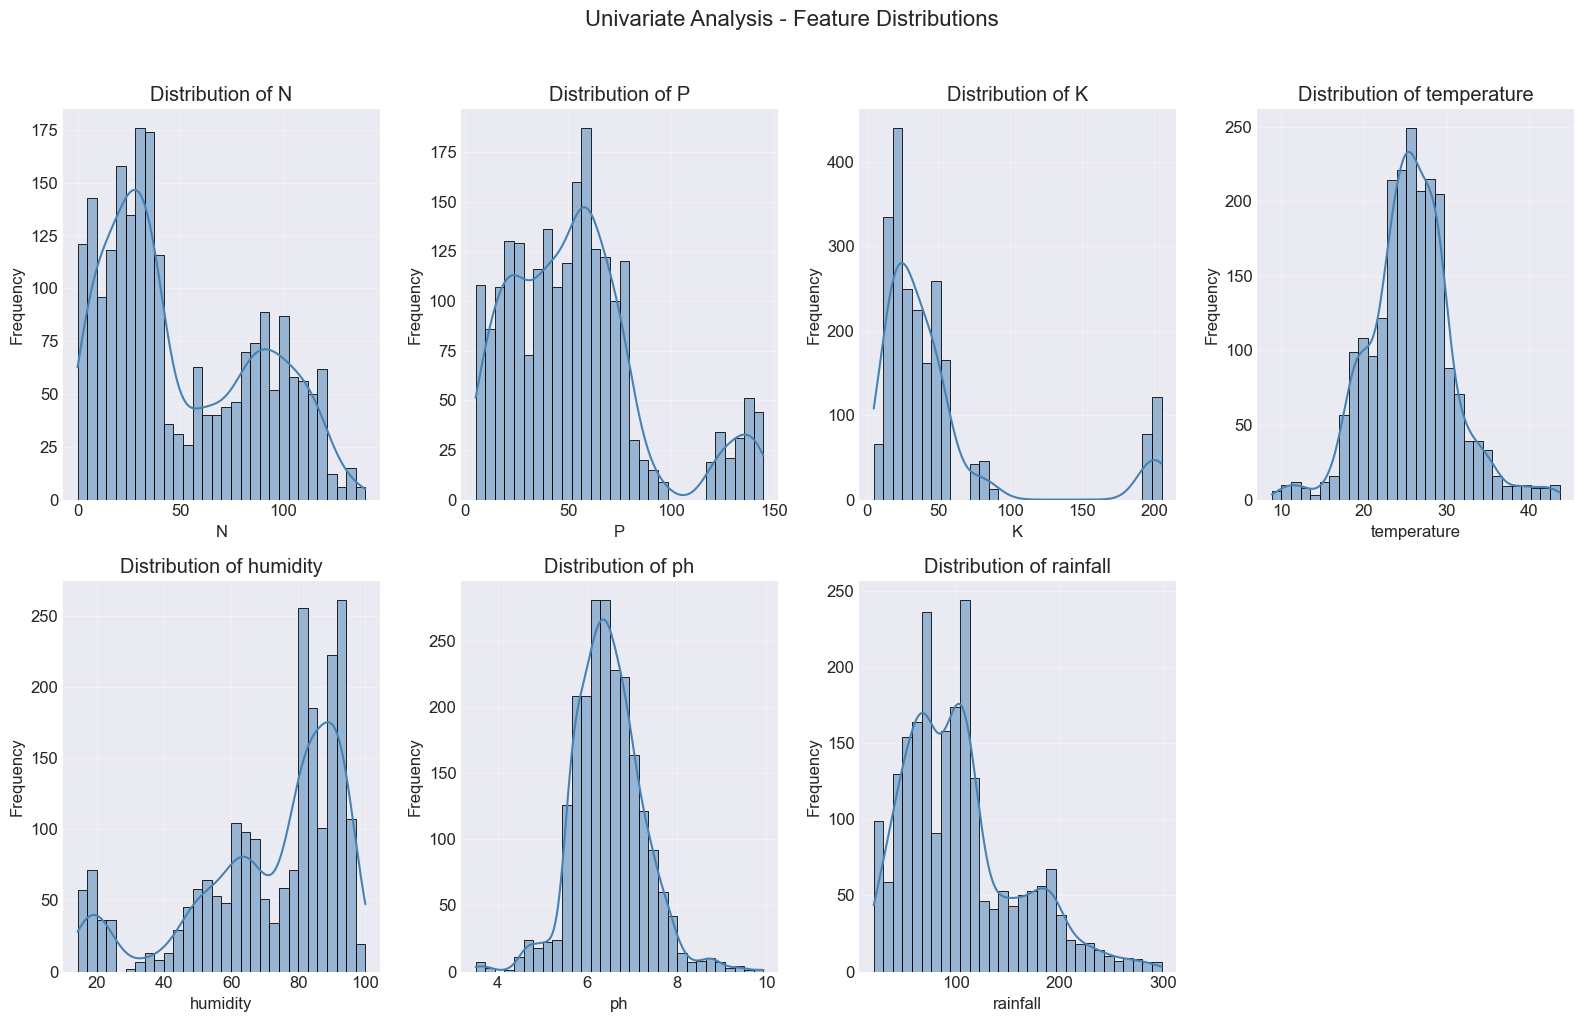

In [19]:
# ============================================
# 1. UNIVARIATE ANALYSIS
# ============================================
print("\n" + "="*70)
print("📈 1. UNIVARIATE ANALYSIS")
print("="*70)

# 1.1 Histograms with KDE for all features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for idx, col in enumerate(features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='steelblue', bins=30)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Remove empty subplot
axes[7].set_visible(False)

plt.suptitle('Univariate Analysis - Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/01_univariate_histograms.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/01_univariate_histograms.png")
plt.show()

✅ Saved: plots/02_univariate_boxplots.png


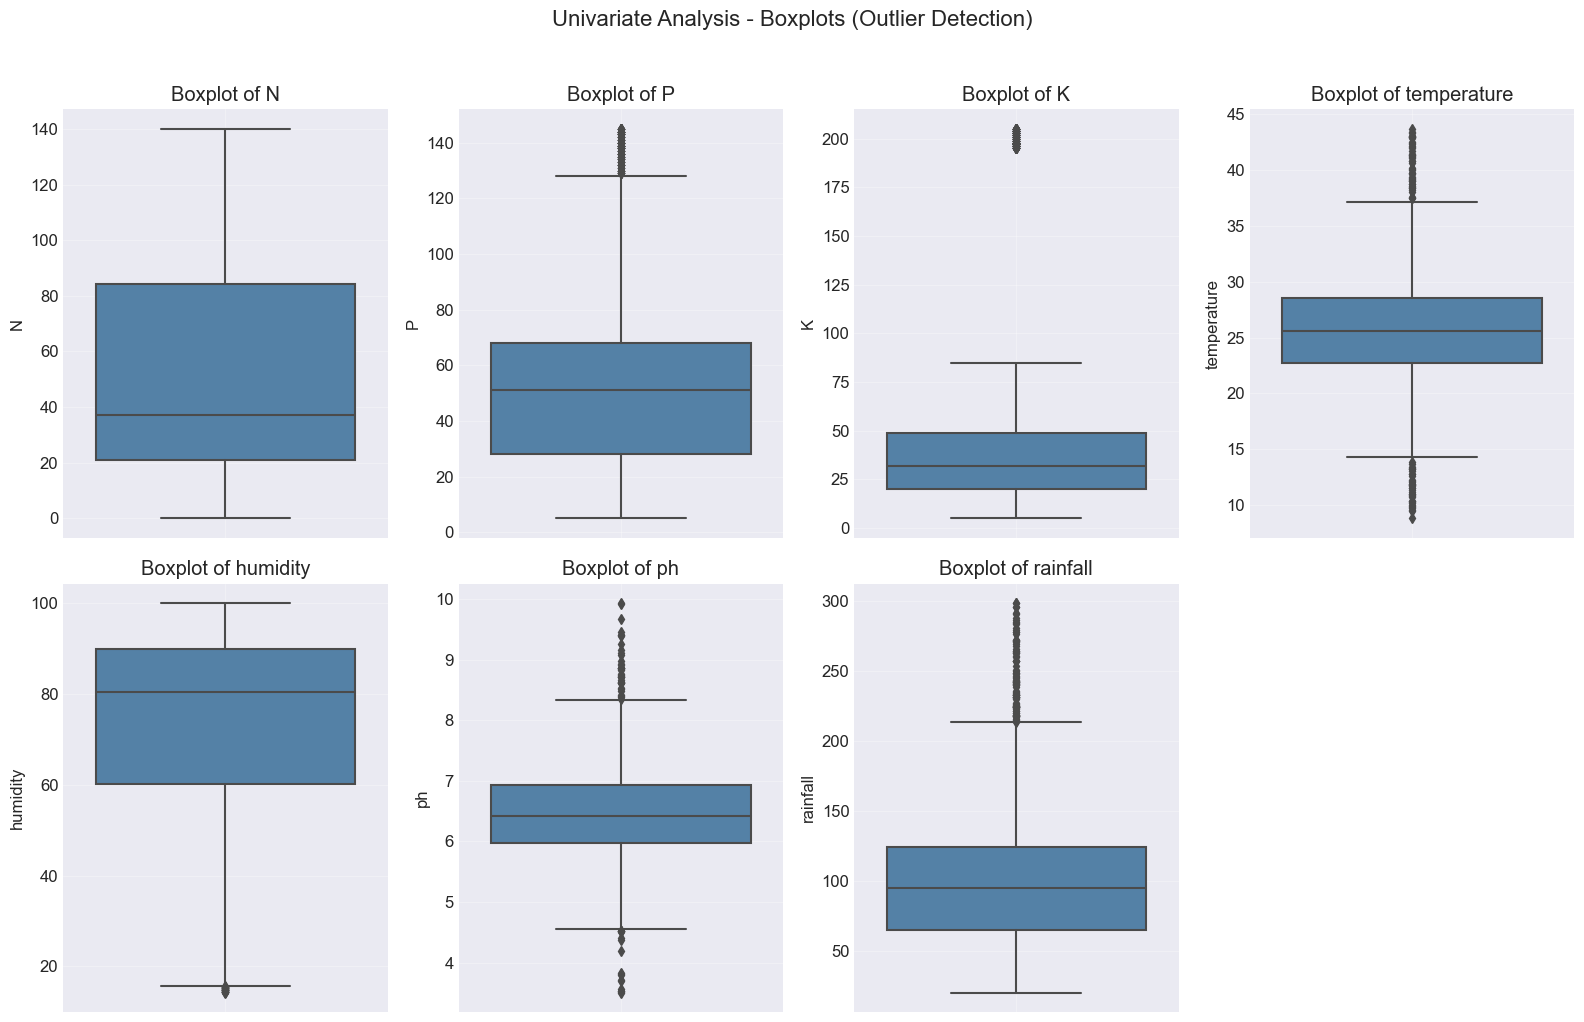

In [20]:
# 1.2 Box plots for all features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

axes[7].set_visible(False)

plt.suptitle('Univariate Analysis - Boxplots (Outlier Detection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/02_univariate_boxplots.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/02_univariate_boxplots.png")
plt.show()

✅ Saved: plots/03_univariate_violinplots.png


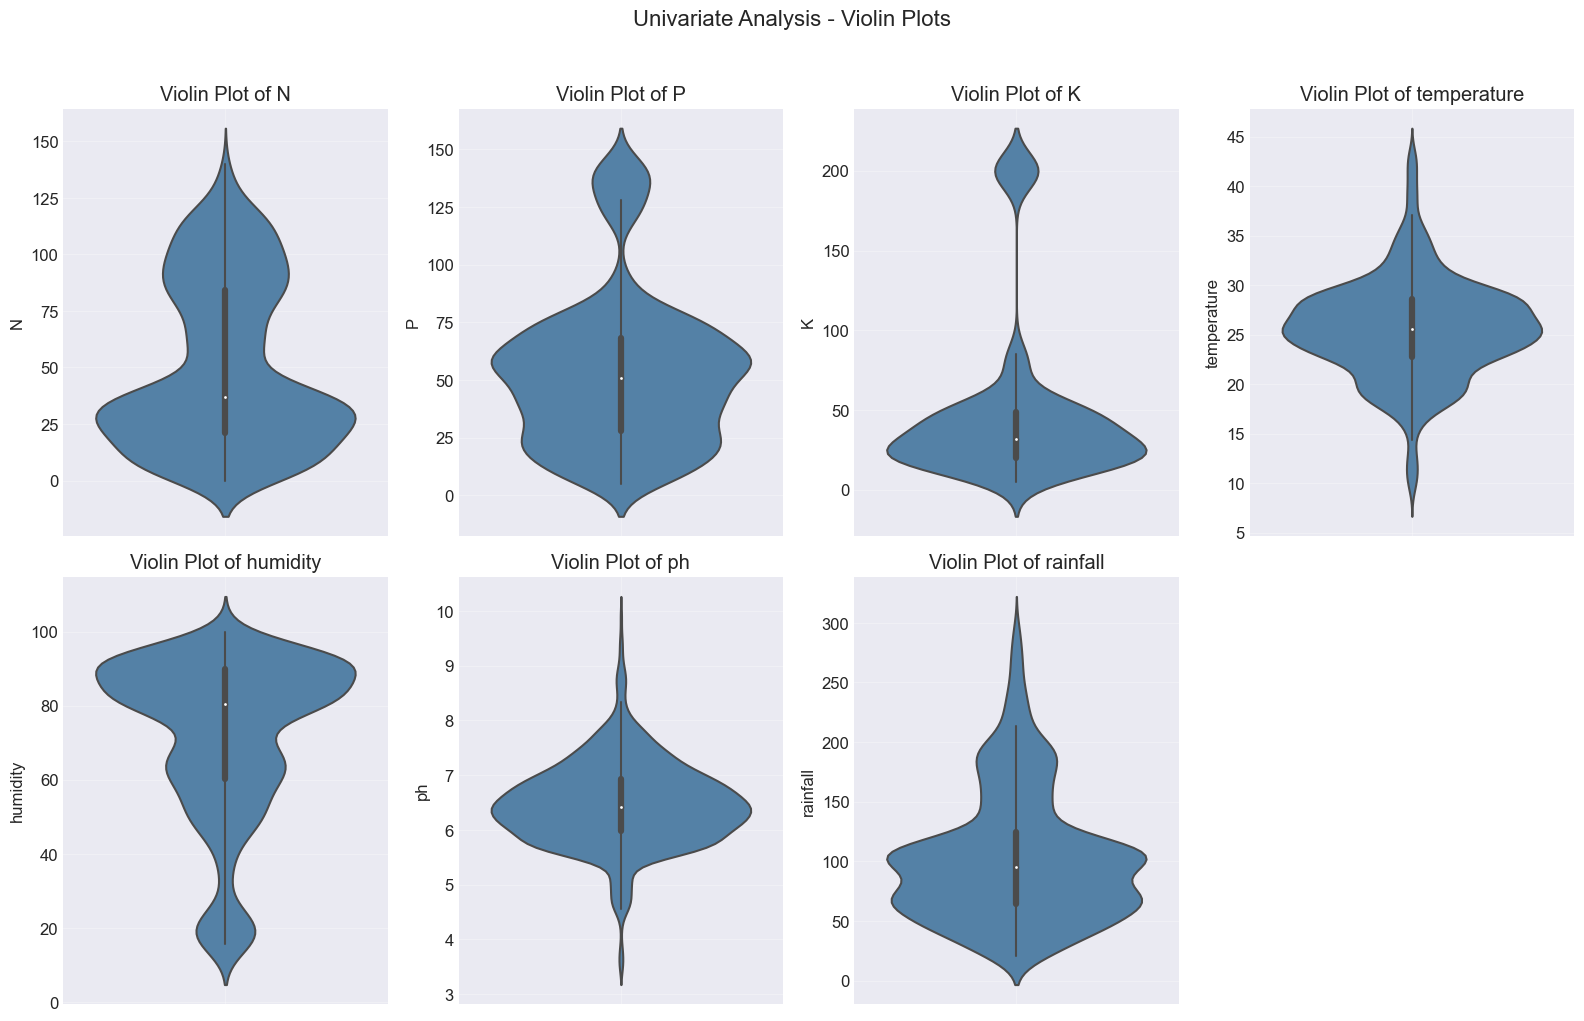

In [21]:
# 1.3 Violin plots for all features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.violinplot(data=df, y=col, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Violin Plot of {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

axes[7].set_visible(False)

plt.suptitle('Univariate Analysis - Violin Plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/03_univariate_violinplots.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/03_univariate_violinplots.png")
plt.show()

✅ Saved: plots/04_univariate_crop_distribution.png


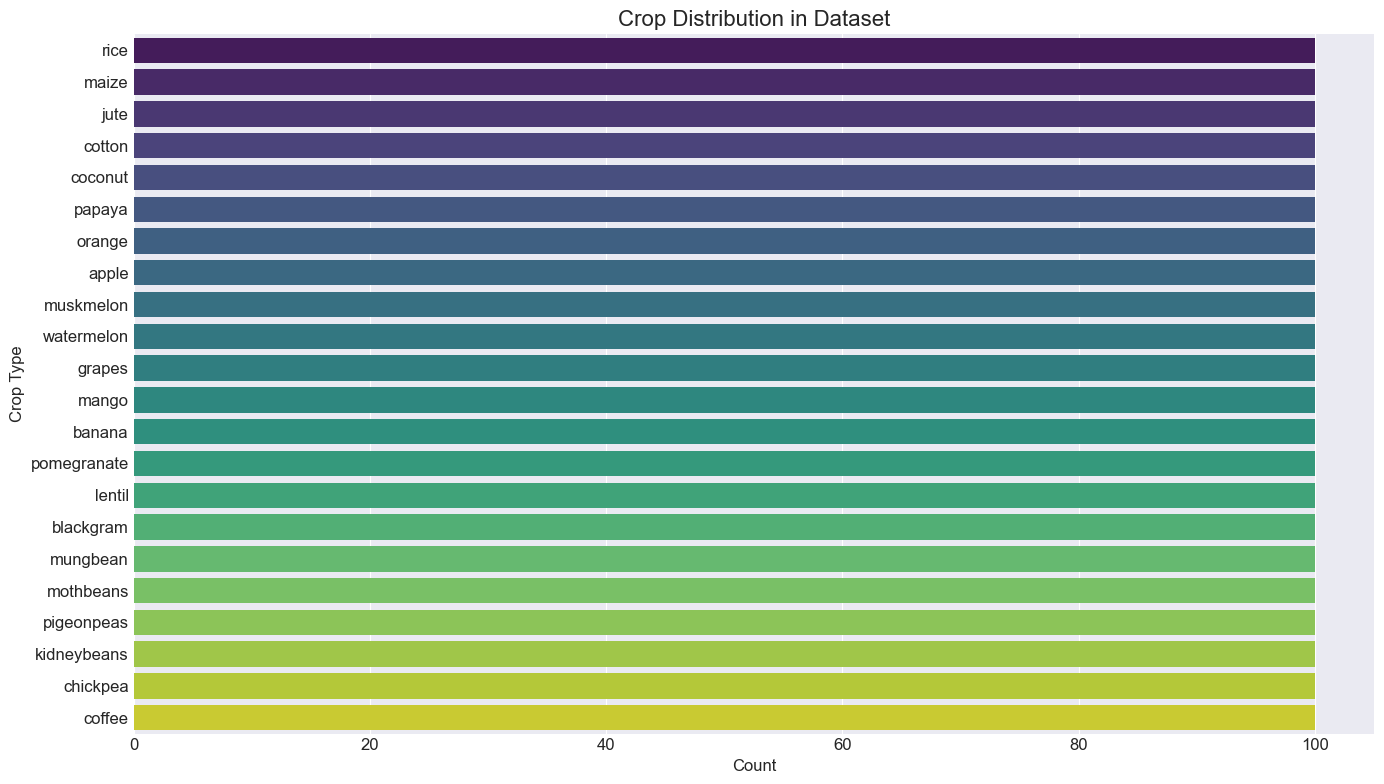

In [22]:
# 1.4 Crop Distribution (Countplot)
plt.figure(figsize=(14, 8))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Crop Distribution in Dataset', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)
plt.tight_layout()
plt.savefig('plots/04_univariate_crop_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/04_univariate_crop_distribution.png")
plt.show()

✅ Saved: plots/05_univariate_crop_pie.png


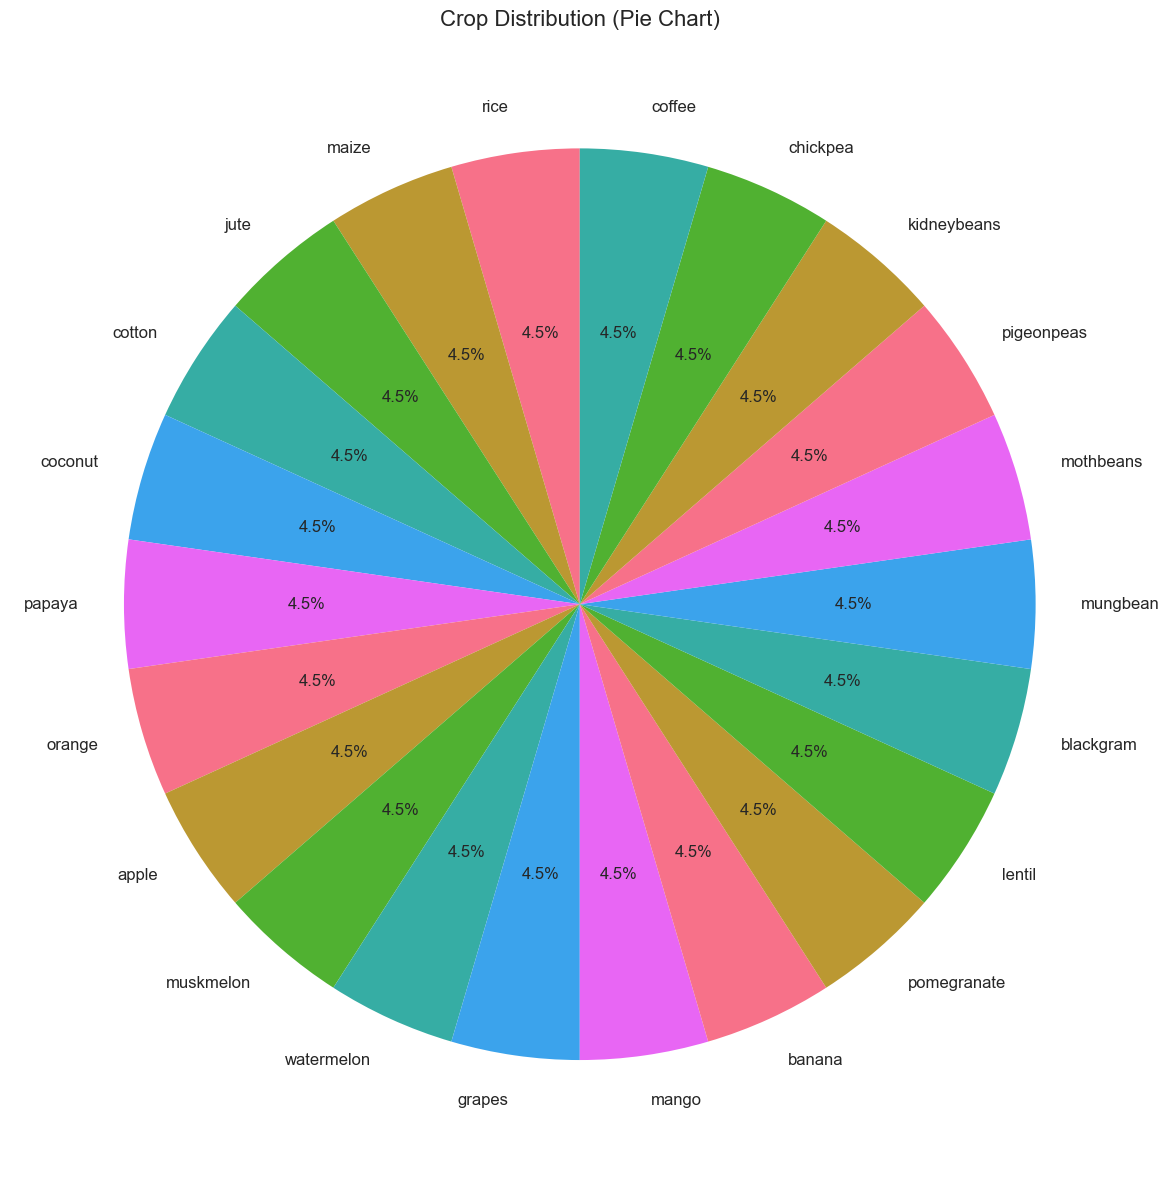

In [23]:
# 1.5 Pie chart of crop distribution
plt.figure(figsize=(12, 12))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Crop Distribution (Pie Chart)', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('plots/05_univariate_crop_pie.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/05_univariate_crop_pie.png")
plt.show()


🔗 2. BIVARIATE ANALYSIS
✅ Saved: plots/06_bivariate_scatter_pairs.png


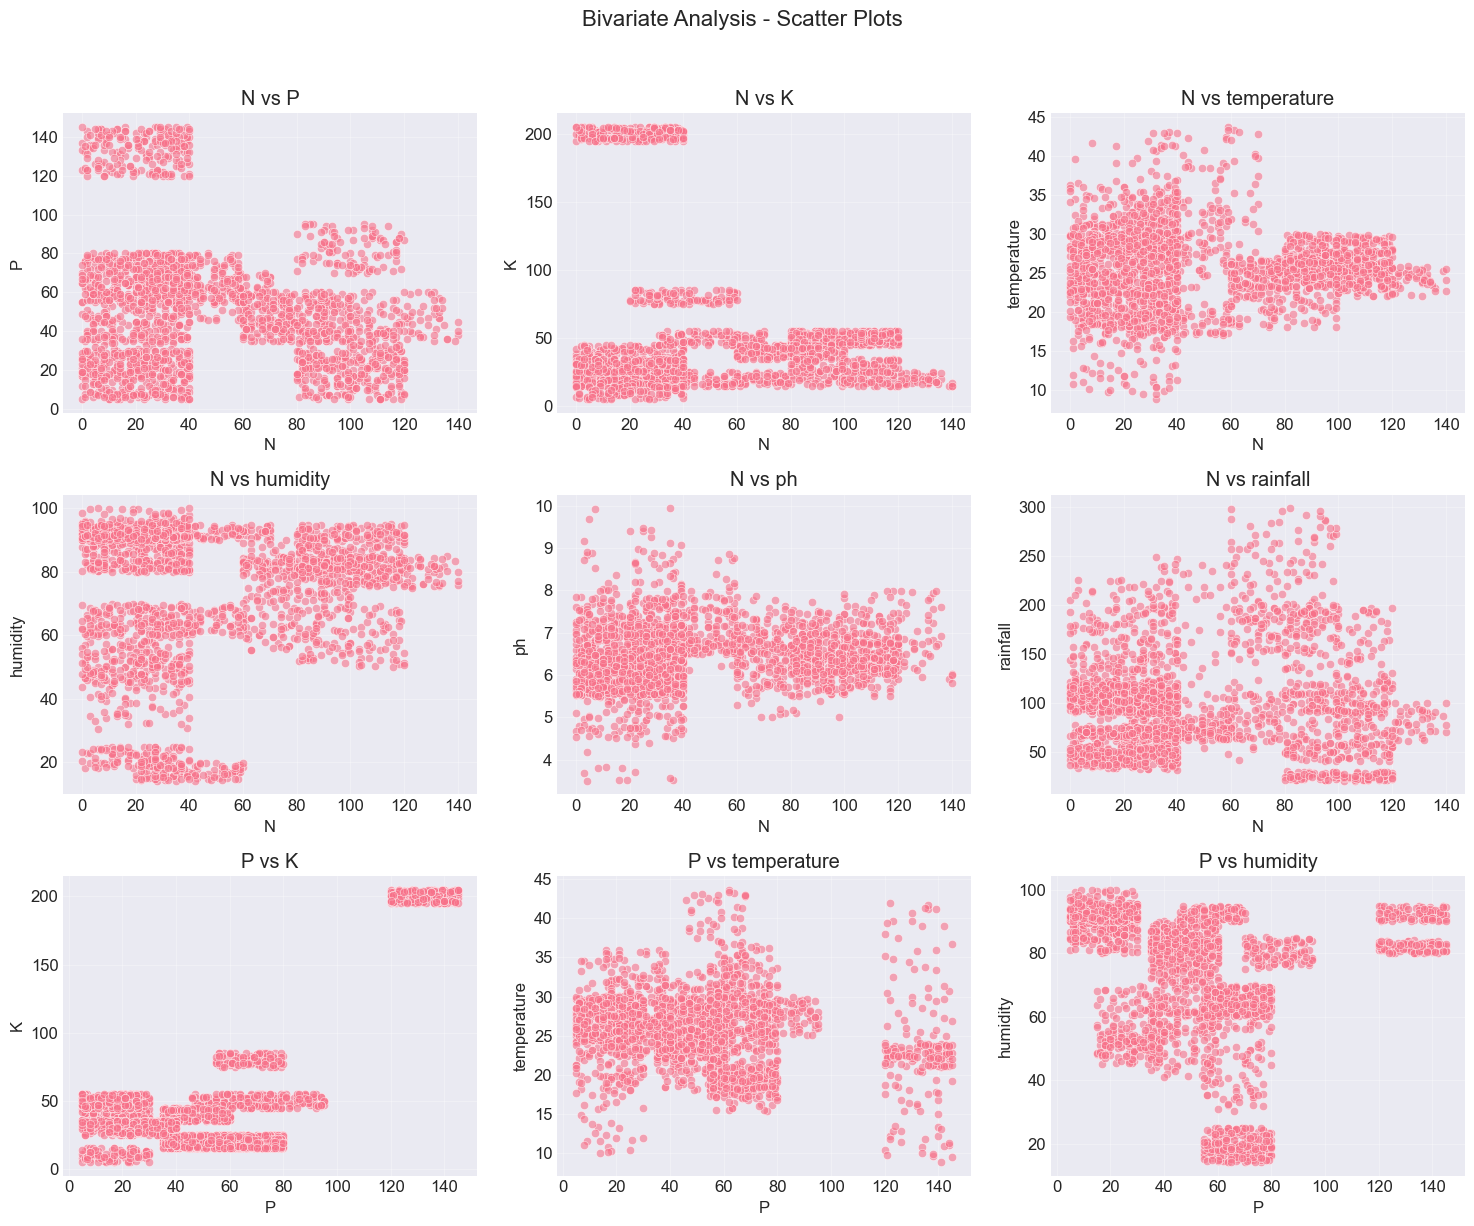

In [24]:
# ============================================
# 2. BIVARIATE ANALYSIS
# ============================================
print("\n" + "="*70)
print("🔗 2. BIVARIATE ANALYSIS")
print("="*70)

# 2.1 Scatter plots: All feature pairs
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

pair_idx = 0
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if pair_idx < 9:
            sns.scatterplot(data=df, x=features[i], y=features[j], ax=axes[pair_idx], alpha=0.6)
            axes[pair_idx].set_title(f'{features[i]} vs {features[j]}')
            axes[pair_idx].grid(True, alpha=0.3)
            pair_idx += 1

# Remove empty subplots
for idx in range(pair_idx, 9):
    axes[idx].set_visible(False)

plt.suptitle('Bivariate Analysis - Scatter Plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/06_bivariate_scatter_pairs.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/06_bivariate_scatter_pairs.png")
plt.show()

✅ Saved: plots/07_bivariate_humidity_temp.png


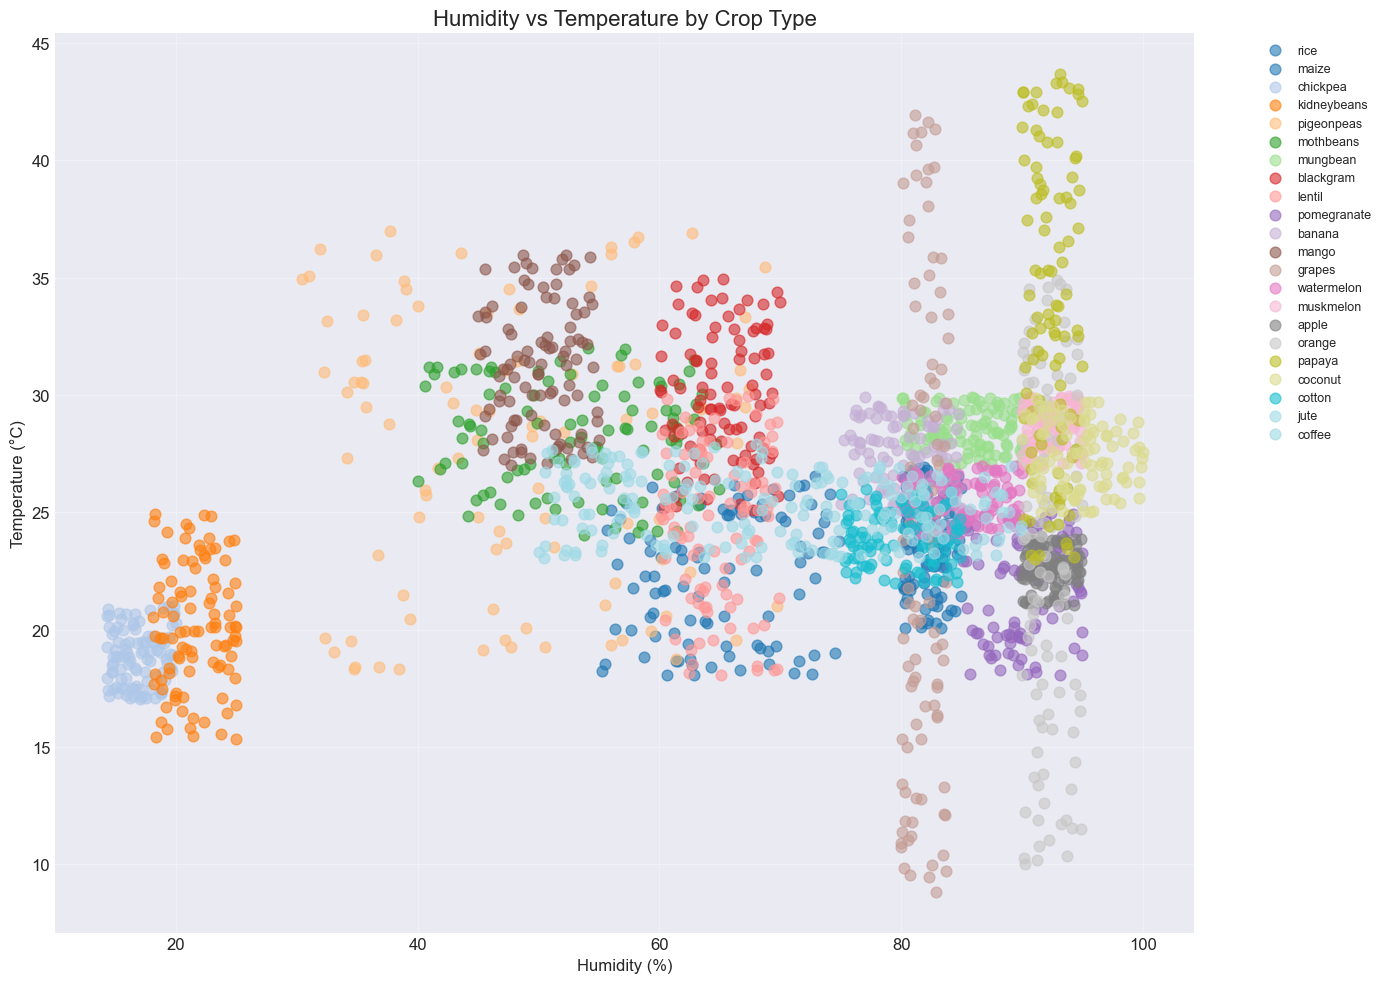

In [25]:
# 2.2 Scatter plot: Humidity vs Temperature by Crop
plt.figure(figsize=(14, 10))
crops = df['label'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(crops)))

for idx, crop in enumerate(crops):
    crop_data = df[df['label'] == crop]
    plt.scatter(crop_data['humidity'], crop_data['temperature'], 
               label=crop, alpha=0.6, s=60, color=colors[idx])

plt.xlabel('Humidity (%)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Humidity vs Temperature by Crop Type', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/07_bivariate_humidity_temp.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/07_bivariate_humidity_temp.png")
plt.show()

✅ Saved: plots/08_bivariate_N_vs_P.png


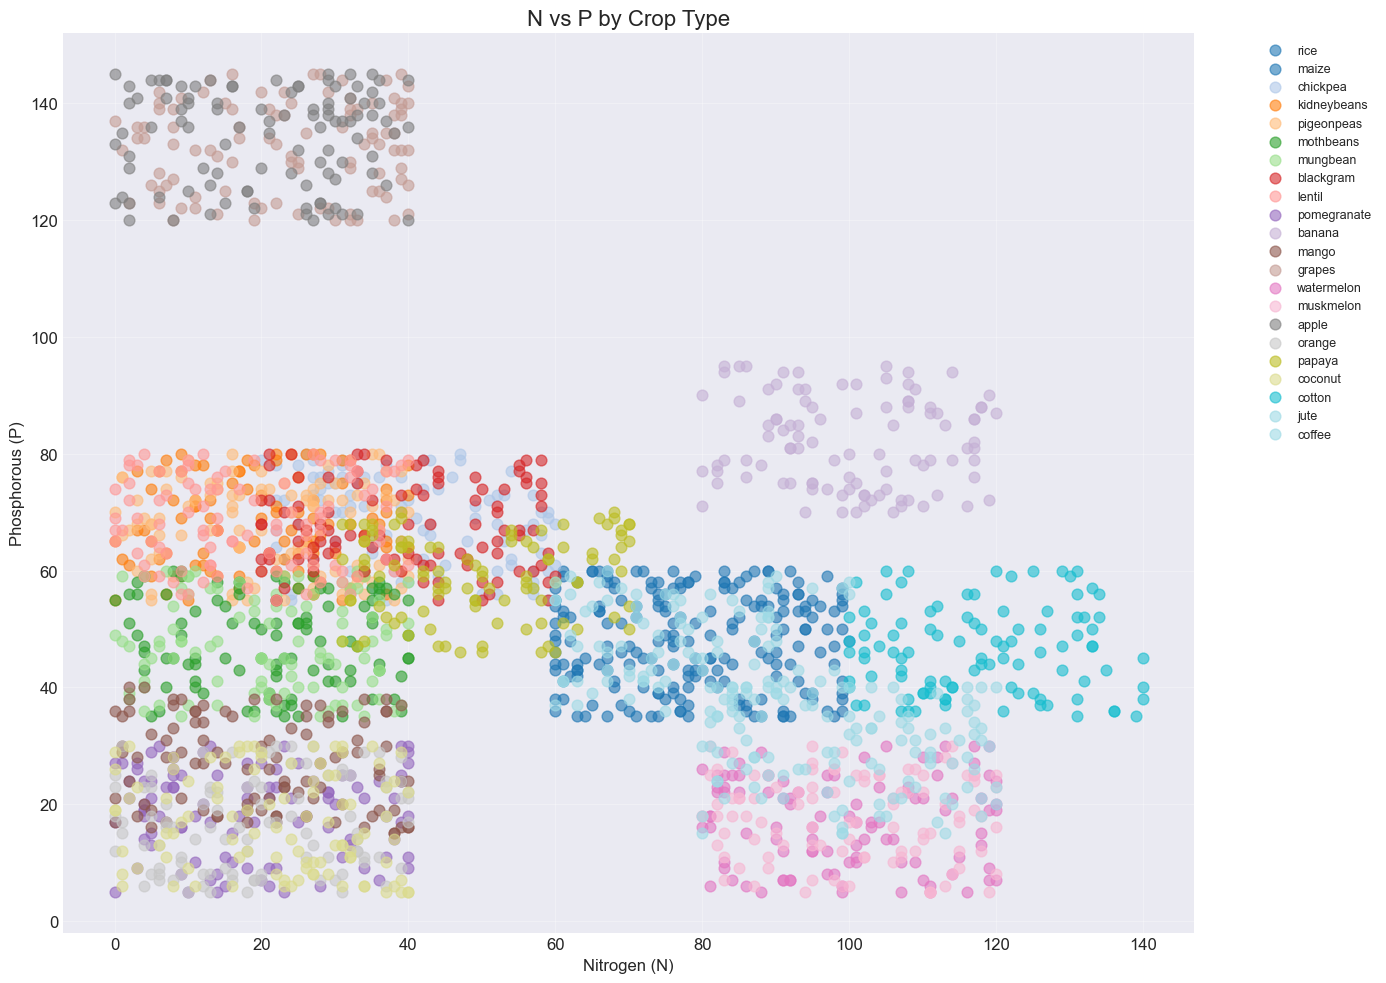

In [26]:
# 2.3 Scatter plot: N vs P by Crop
plt.figure(figsize=(14, 10))
for idx, crop in enumerate(crops):
    crop_data = df[df['label'] == crop]
    plt.scatter(crop_data['N'], crop_data['P'], 
               label=crop, alpha=0.6, s=60, color=colors[idx])

plt.xlabel('Nitrogen (N)', fontsize=12)
plt.ylabel('Phosphorous (P)', fontsize=12)
plt.title('N vs P by Crop Type', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/08_bivariate_N_vs_P.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/08_bivariate_N_vs_P.png")
plt.show()

✅ Saved: plots/09_bivariate_K_vs_temp.png


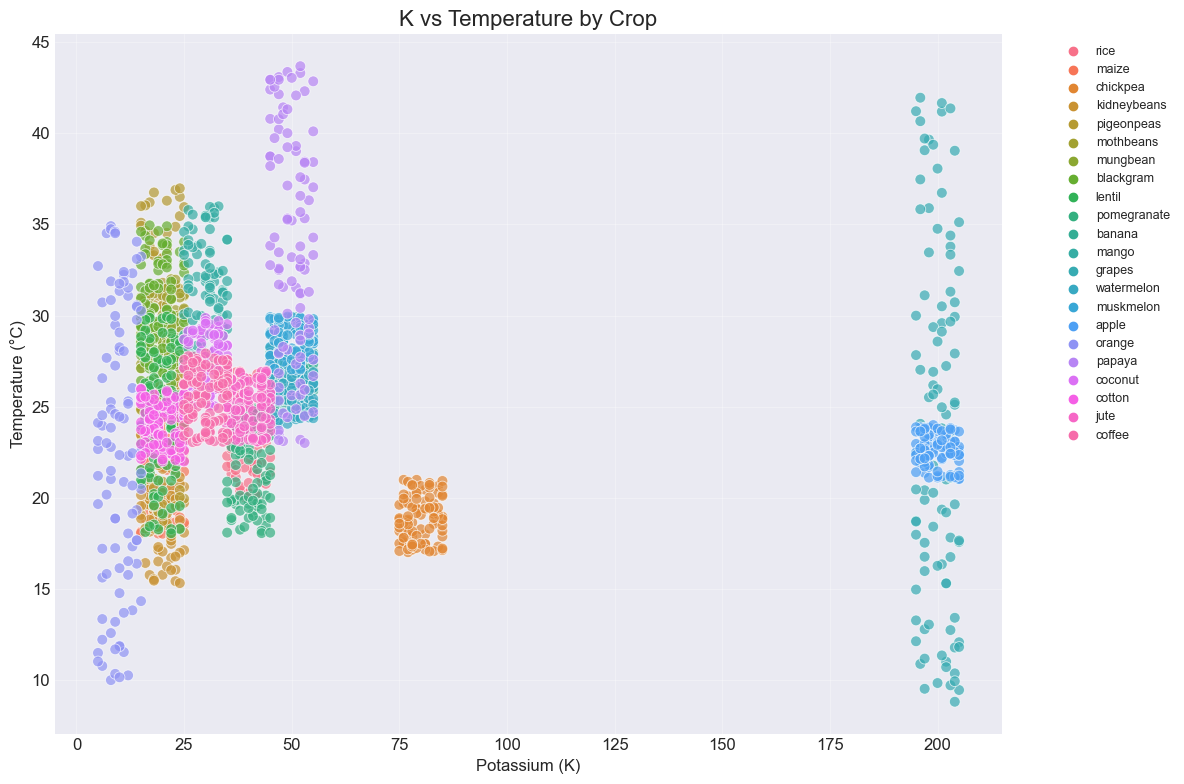

In [27]:
# 2.4 Scatter plot: K vs Temperature
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='K', y='temperature', hue='label', alpha=0.7, s=60)
plt.xlabel('Potassium (K)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('K vs Temperature by Crop', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/09_bivariate_K_vs_temp.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/09_bivariate_K_vs_temp.png")
plt.show()

✅ Saved: plots/10_bivariate_pH_vs_rainfall.png


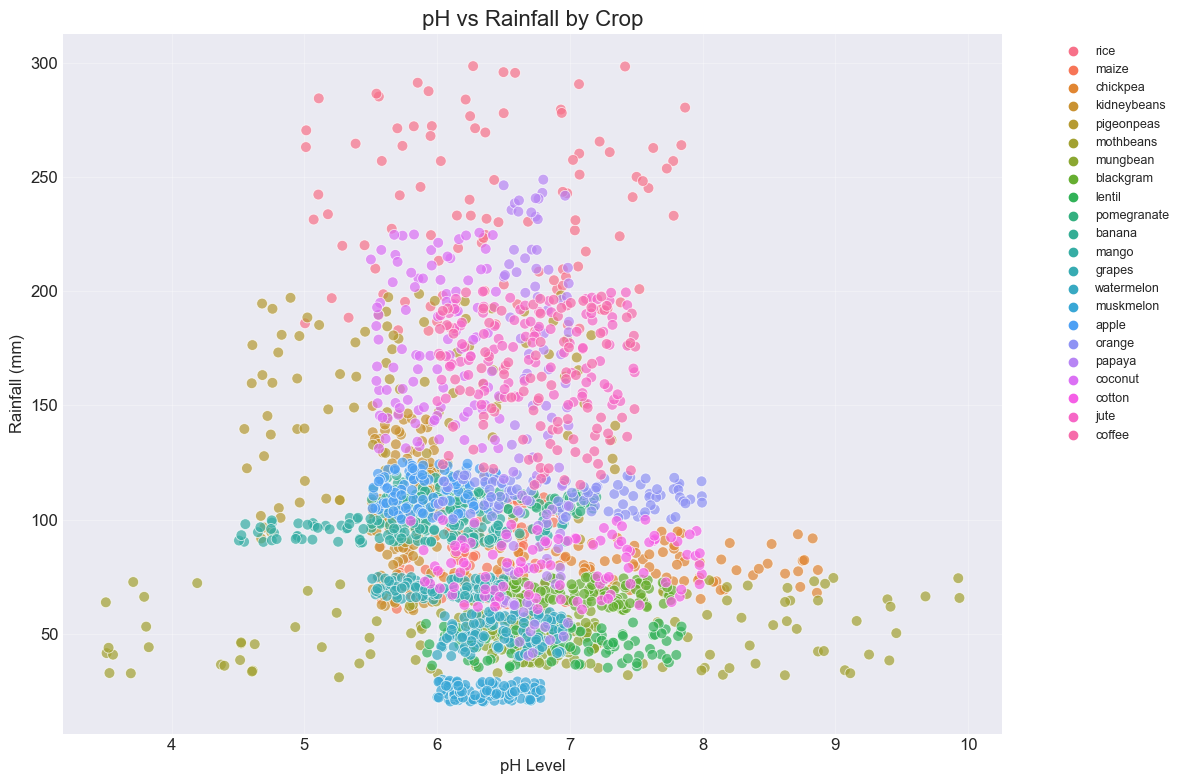

In [28]:
# 2.5 Scatter plot: pH vs Rainfall
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='ph', y='rainfall', hue='label', alpha=0.7, s=60)
plt.xlabel('pH Level', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.title('pH vs Rainfall by Crop', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_bivariate_pH_vs_rainfall.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/10_bivariate_pH_vs_rainfall.png")
plt.show()

✅ Saved: plots/11_bivariate_correlation_heatmap.png


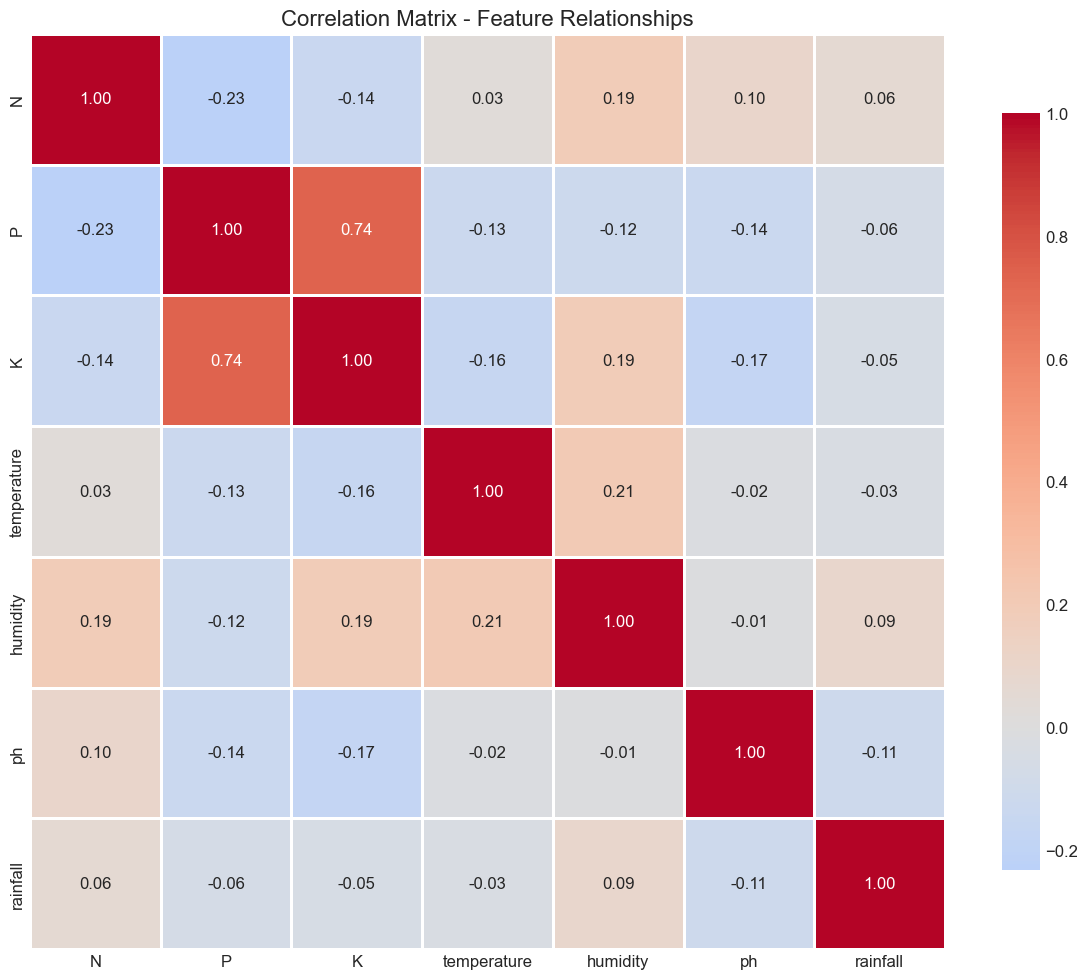

In [29]:
# 2.6 Correlation between features (Heatmap)
plt.figure(figsize=(12, 10))
correlation = df[features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, 
            linewidths=2, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Feature Relationships', fontsize=16)
plt.tight_layout()
plt.savefig('plots/11_bivariate_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/11_bivariate_correlation_heatmap.png")
plt.show()


🎯 3. MULTIVARIATE ANALYSIS
✅ Saved: plots/12_multivariate_pairplot.png


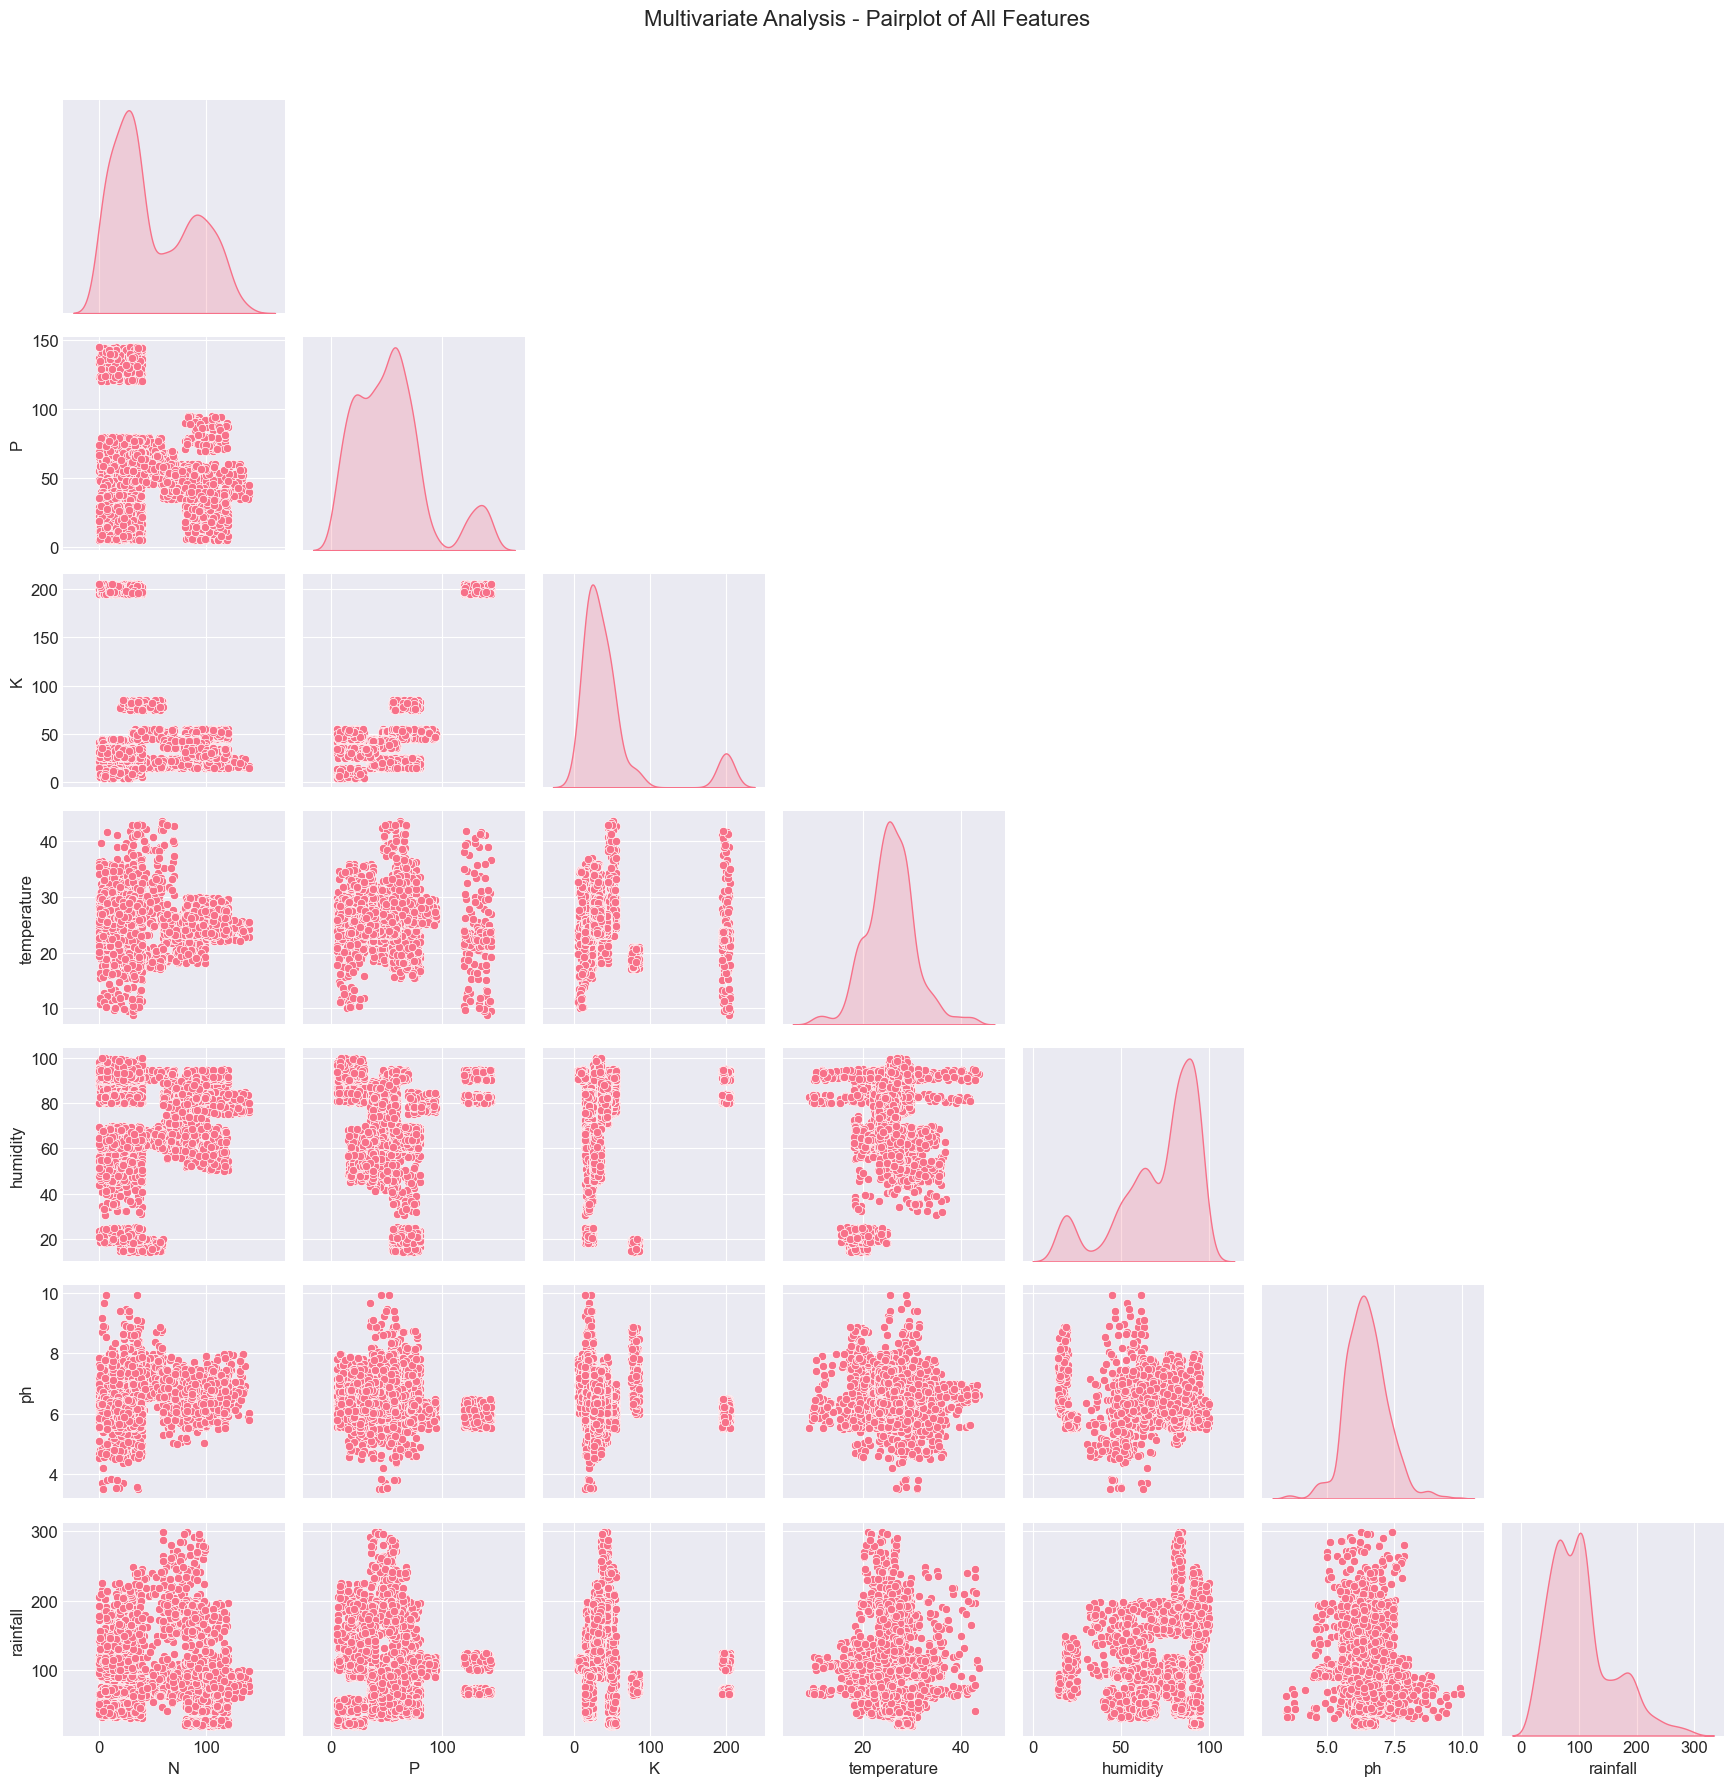

In [30]:
# ============================================
# 3. MULTIVARIATE ANALYSIS
# ============================================
print("\n" + "="*70)
print("🎯 3. MULTIVARIATE ANALYSIS")
print("="*70)

# 3.1 Pairplot for all features
sns.pairplot(df[features], diag_kind='kde', corner=True)
plt.suptitle('Multivariate Analysis - Pairplot of All Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/12_multivariate_pairplot.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/12_multivariate_pairplot.png")
plt.show()

✅ Saved: plots/13_multivariate_pairplot_by_crop.png


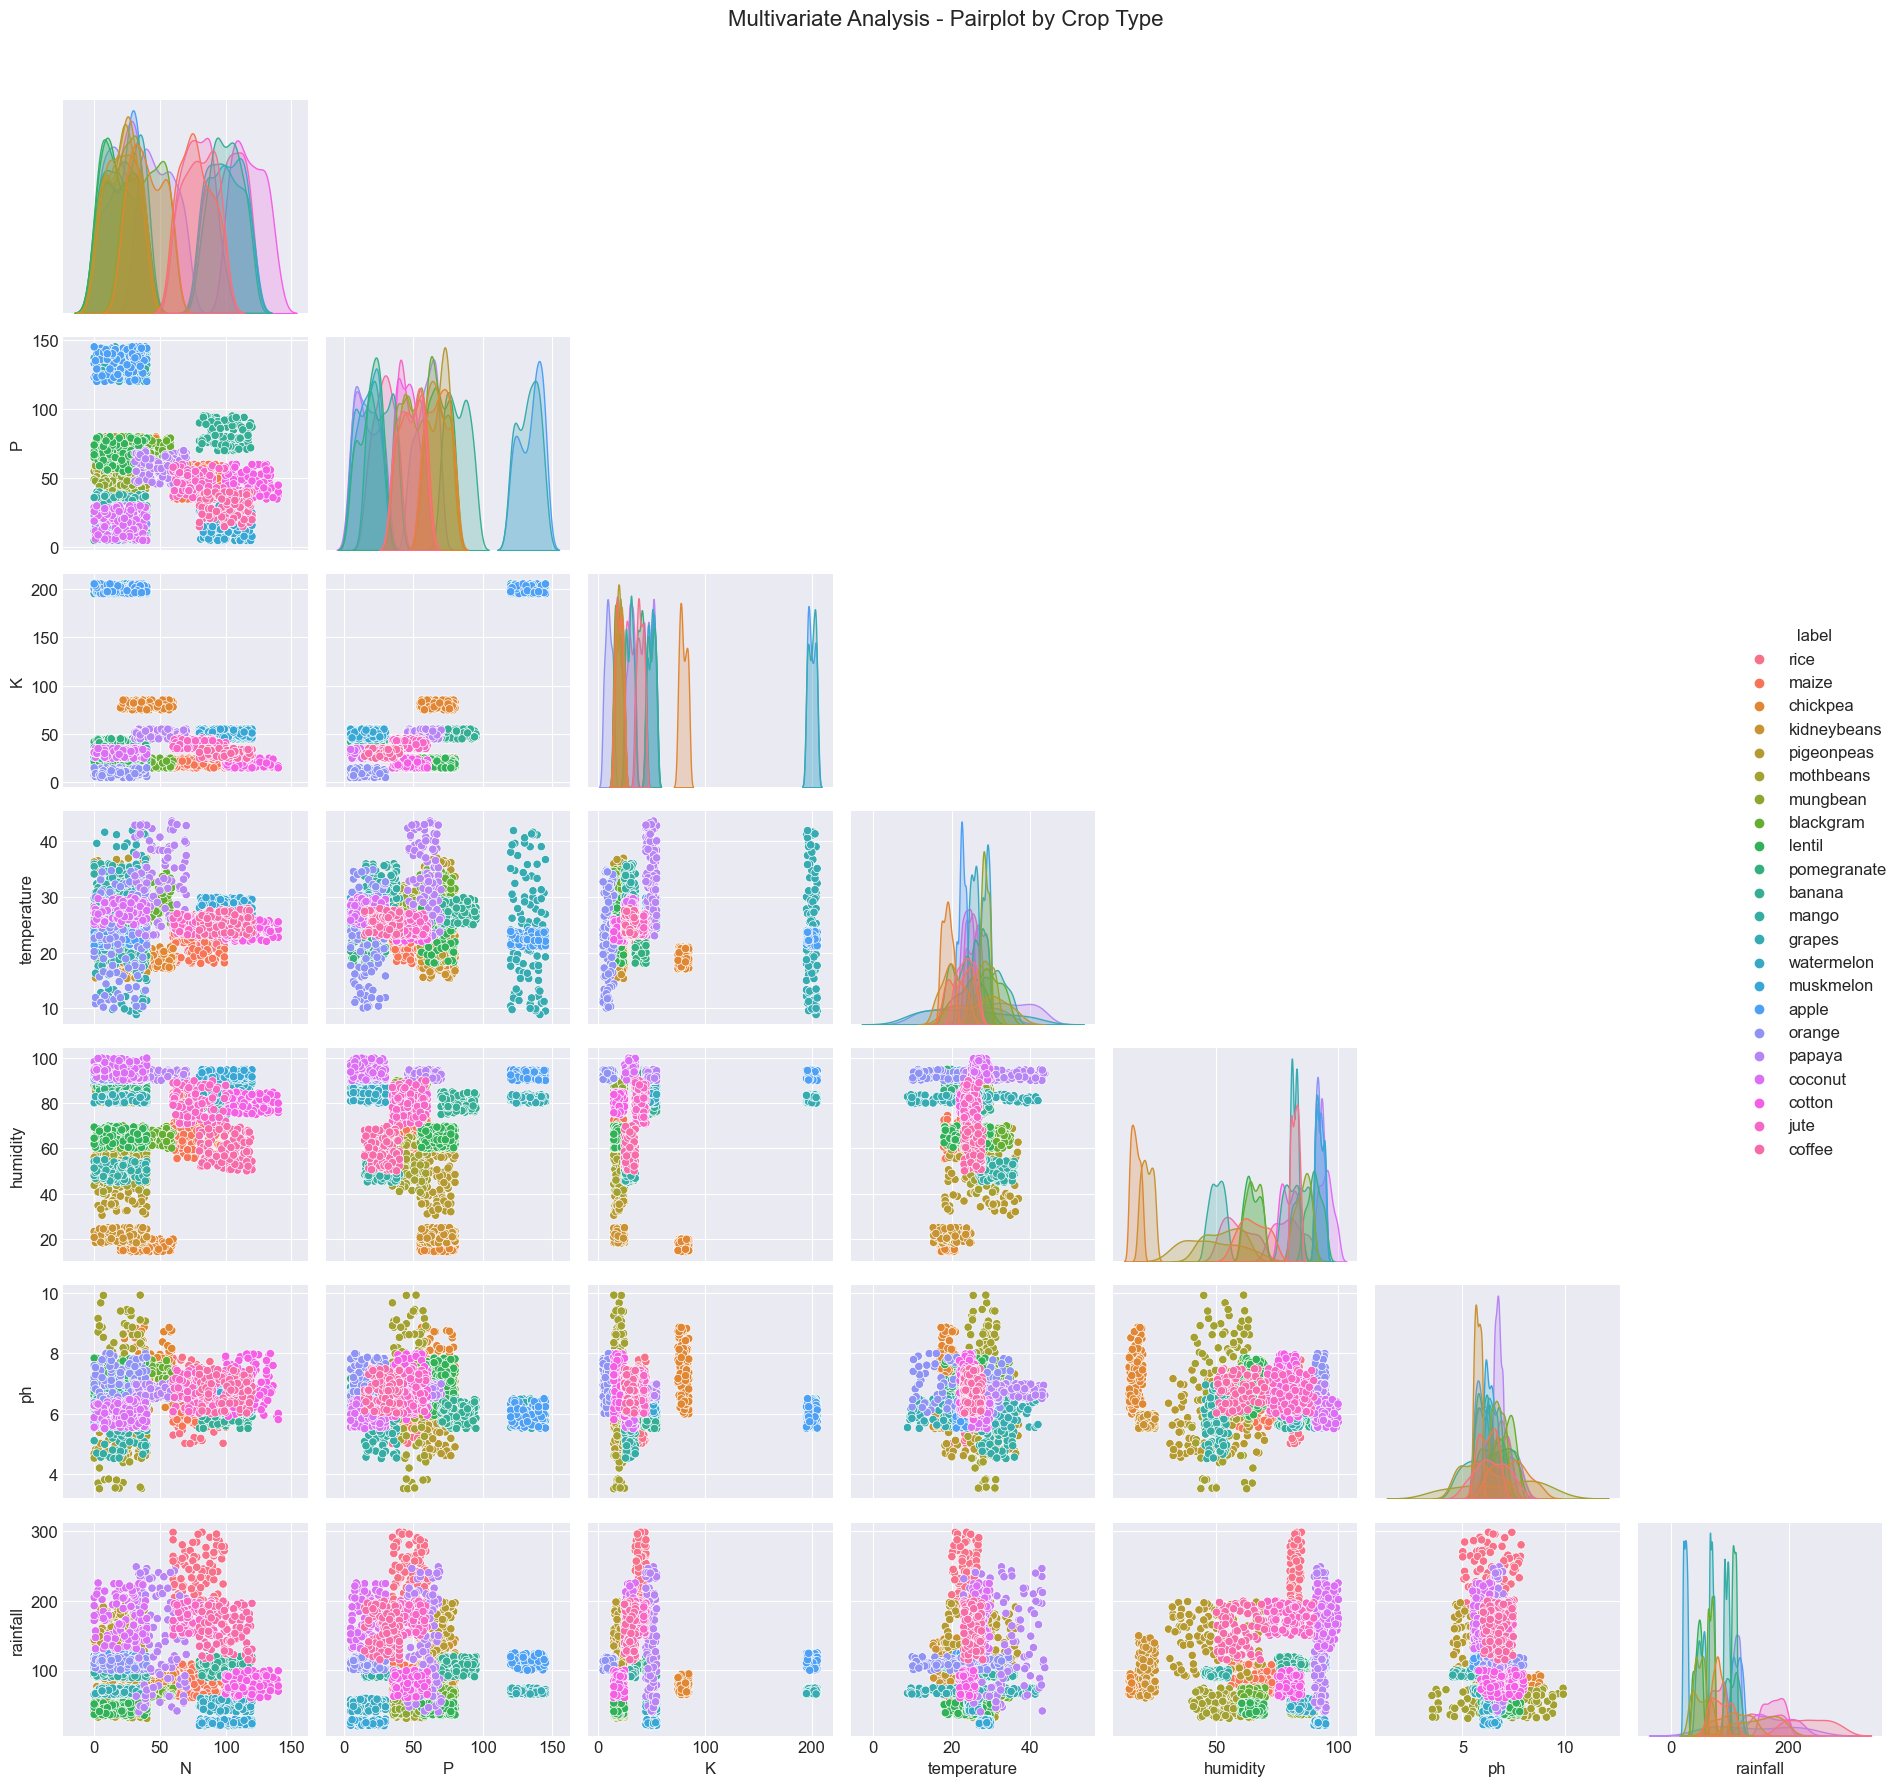

In [33]:
# 3.2 Pairplot with crop labels
sns.pairplot(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']], 
             hue='label', diag_kind='kde', corner=True, palette='husl')
plt.suptitle('Multivariate Analysis - Pairplot by Crop Type', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/13_multivariate_pairplot_by_crop.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/13_multivariate_pairplot_by_crop.png")
plt.show()

✅ Saved: plots/14_multivariate_feature_importance.png


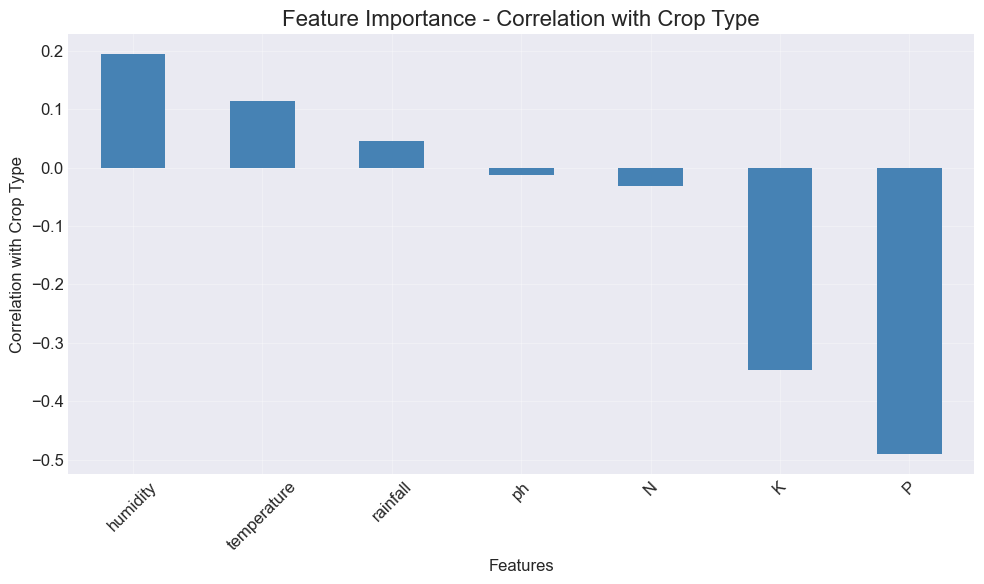

In [32]:
# 3.3 Feature Importance (based on correlation with target)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['label_encoded'] = le.fit_transform(df['label'])

feature_importance = df_encoded[features + ['label_encoded']].corr()['label_encoded'].drop('label_encoded').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - Correlation with Crop Type', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Crop Type', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14_multivariate_feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/14_multivariate_feature_importance.png")
plt.show()

✅ Saved: plots/15_multivariate_clustermap.png


<Figure size 1200x1000 with 0 Axes>

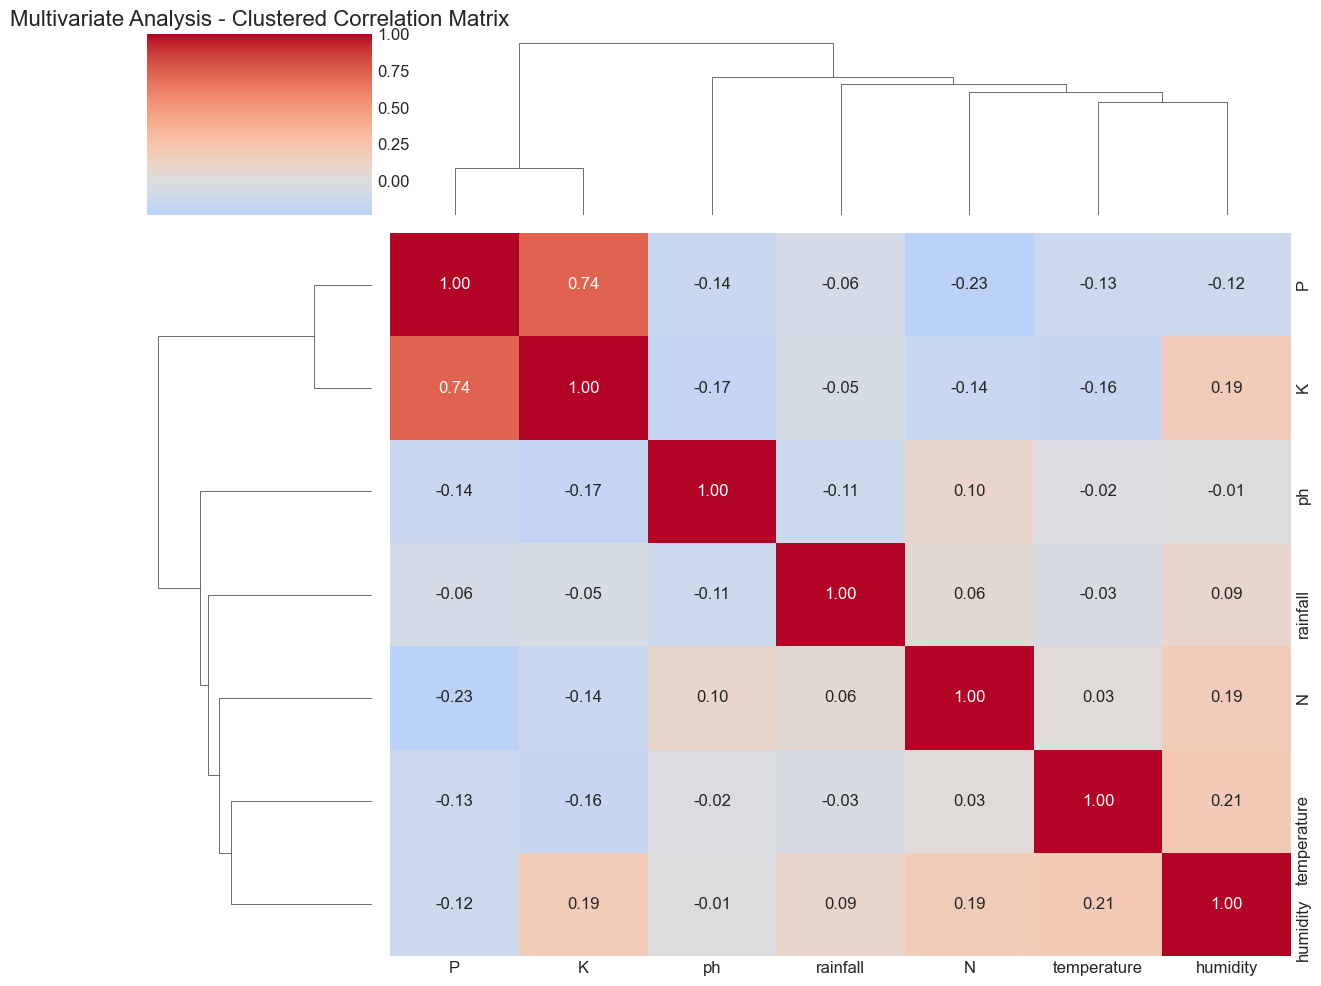

In [34]:
# 3.4 Cluster Map
plt.figure(figsize=(12, 10))
sns.clustermap(df[features].corr(), annot=True, cmap='coolwarm', center=0, 
               fmt='.2f', figsize=(12, 10))
plt.title('Multivariate Analysis - Clustered Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('plots/15_multivariate_clustermap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/15_multivariate_clustermap.png")
plt.show()

✅ Saved: plots/16_multivariate_radar_chart.png


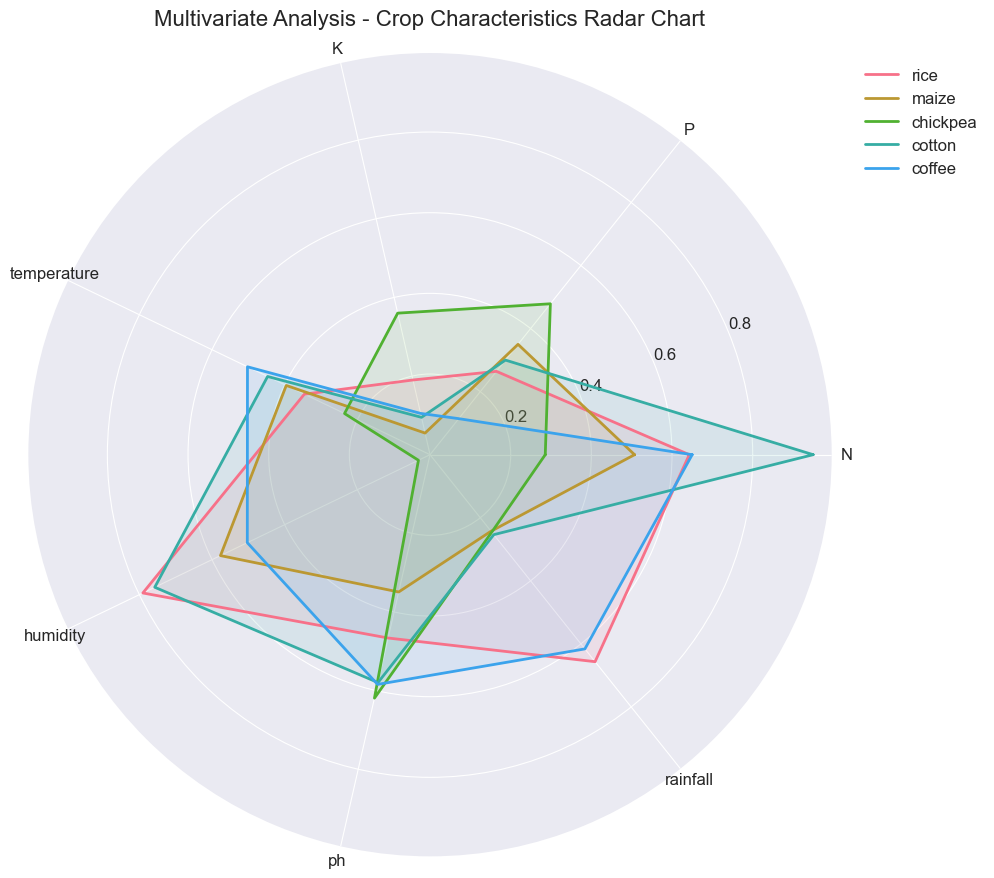

In [35]:
# 3.5 Radar chart for crop characteristics (for top crops)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
df_scaled['label'] = df['label'].values

top_crops = ['rice', 'maize', 'chickpea', 'cotton', 'coffee']
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

for crop in top_crops:
    crop_data = df_scaled[df_scaled['label'] == crop].iloc[0]
    values = crop_data[features].values.tolist()
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]
    ax.plot(angles, values, label=crop, linewidth=2)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(np.linspace(0, 2 * np.pi, len(features), endpoint=False))
ax.set_xticklabels(features)
plt.title('Multivariate Analysis - Crop Characteristics Radar Chart', fontsize=16, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.tight_layout()
plt.savefig('plots/16_multivariate_radar_chart.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/16_multivariate_radar_chart.png")
plt.show()

✅ Saved: plots/17_multivariate_3d_scatter.png


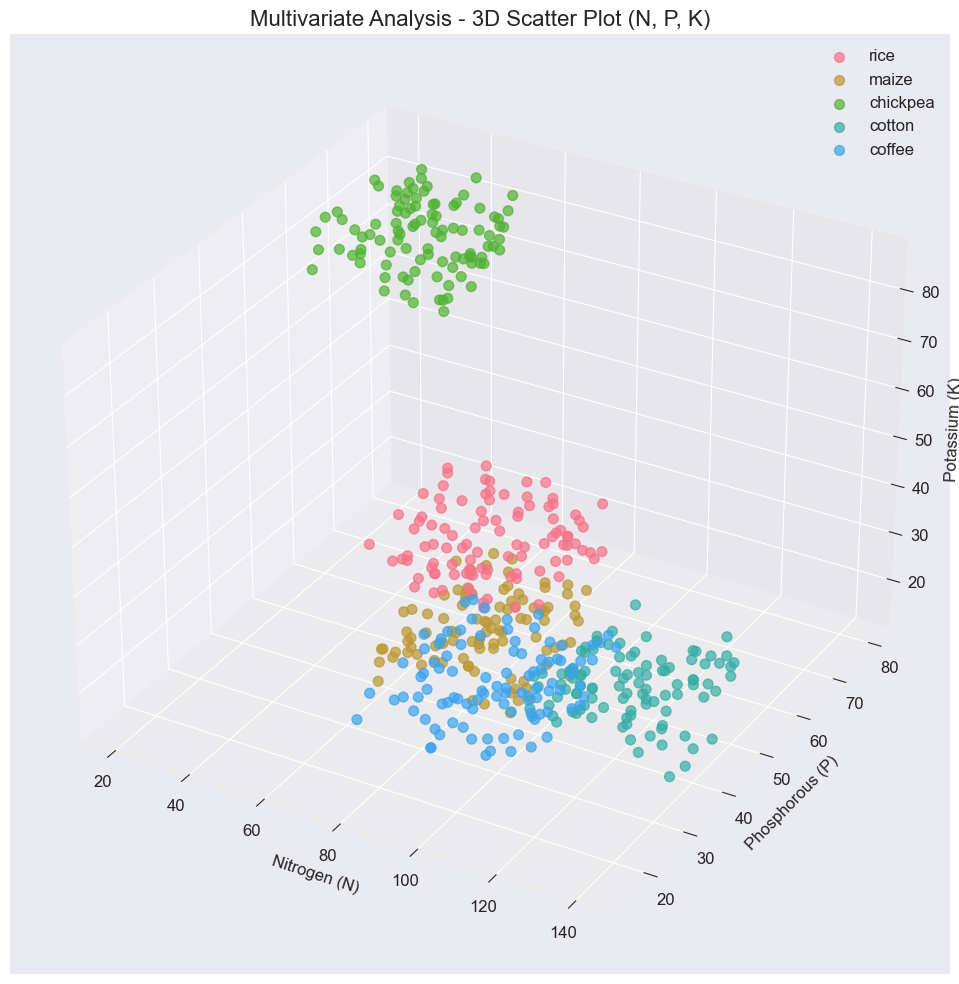

In [36]:
# 3.6 3D Scatter plot (Interactive)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for idx, crop in enumerate(['rice', 'maize', 'chickpea', 'cotton', 'coffee']):
    crop_data = df[df['label'] == crop]
    ax.scatter(crop_data['N'], crop_data['P'], crop_data['K'], 
               label=crop, s=50, alpha=0.7)

ax.set_xlabel('Nitrogen (N)')
ax.set_ylabel('Phosphorous (P)')
ax.set_zlabel('Potassium (K)')
plt.title('Multivariate Analysis - 3D Scatter Plot (N, P, K)', fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig('plots/17_multivariate_3d_scatter.png', dpi=300, bbox_inches='tight')
print("✅ Saved: plots/17_multivariate_3d_scatter.png")
plt.show()

In [37]:
print("\n" + "="*70)
print("✅ EDA COMPLETED SUCCESSFULLY!")
print(f"📁 All plots saved in 'plots/' folder")
print(f"📊 Total plots generated: 17")
print("="*70)


✅ EDA COMPLETED SUCCESSFULLY!
📁 All plots saved in 'plots/' folder
📊 Total plots generated: 17
